# ML, GBERT, and Gemini: Held-Out Test Comparison

Run Cells 2-4 for the full comparison; Cell 5 optionally exports aggregate metrics. ML settings are selected on dev only, and all three models are evaluated on the same candidate rows. Gemini receives each complete, ordered reflection and returns one prediction per segment in that document. It runs once per test document for end-to-end scoring and once per document for the gold-scope diagnostic. Test text is sent to Google Gemini and, when configured, LangSmith; requests use the protected shared rate limiter. The saved-artifact evaluation below is a separate workflow and is not required for this comparison.

The selected GBERT run is `retrain-20261003T125604532027Z`, using the direct scope-plus-three-skills cascade. Every checkpoint fingerprint and its recorded scope/wide split hashes are checked against the current files before inference. Metadata must confirm dev-only checkpoint selection and no use of test for training.

ML settings are selected from the existing grid on train/dev only, then frozen before test scoring. Scope, gold-in-scope skill diagnostics, and end-to-end `N/0/1/2/3` tasks use the same scorer and candidate rows. Alternative annotations remain separate. Fixed-label macro-F1 and gold-supported macro-F1 are both reported because SW band C has no test examples.

The comparison scores all 905 candidates, representing 903 unique segments and 24 test documents. Whole-reflection predictions are mapped to every candidate annotation for the corresponding segment. Do not tune settings from these test results.

In [1]:
from pathlib import Path
from itertools import product
from time import perf_counter
import os

import pandas as pd
import torch
from dotenv import load_dotenv
from IPython.display import display

from reflection_assessment_feedback.experiment_config import load_experiment_config
from reflection_assessment_feedback.segment_classification_ml import MLSettings, SegmentClassifierML
from reflection_assessment_feedback.segment_model_comparison import GBERTPredictor, compare_models

COMPARISON_ROOT = Path.cwd().resolve()
assert (COMPARISON_ROOT / 'config' / 'experiment.toml').is_file(), 'Run from the project root.'
load_dotenv(COMPARISON_ROOT / '.env', override=False)
COMPARISON_CONFIG = load_experiment_config()
COMPARISON_SPLIT_DIR = COMPARISON_ROOT / COMPARISON_CONFIG['paths']['provisional_split_directory']
GBERT_CHECKPOINT_DIR = (
    COMPARISON_ROOT / 'artifacts/segment-classification/retrain-20261003T125604532027Z'
)

RUN_MODEL_COMPARISON = True
RUN_GEMINI_TEST_COMPARISON = True
SELECT_ML_ON_DEV = True
ML_MODEL_PATH = None
GBERT_DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'
SAVE_COMPARISON = False

comparison_result = None
comparison_ml_model = None
comparison_gemini_model = None
ml_dev_comparison = []
print('Full test comparison enabled: dev-only ML selection, retrained direct GBERT, and whole-reflection Gemini.')
print(f'Local GBERT device: {GBERT_DEVICE}; Gemini receives complete reflections when enabled.')

Full test comparison enabled: dev-only ML selection, retrained direct GBERT, and whole-reflection Gemini.
Local GBERT device: mps; Gemini receives complete reflections when enabled.


In [5]:
import hashlib
import json
import math
import warnings

if RUN_MODEL_COMPARISON:
    comparison_splits = {
        split: pd.read_csv(
            COMPARISON_SPLIT_DIR / f'provisional_{split}_modeling_wide.csv',
            dtype={'candidate_id': str, 'segment_id': str, 'document_id': str, 'author_id': str},
        )
        for split in ('train', 'dev', 'test')
    }
    for left, right in [('train', 'dev'), ('train', 'test'), ('dev', 'test')]:
        for column in ('author_id', 'document_id', 'segment_id'):
            if set(comparison_splits[left][column]) & set(comparison_splits[right][column]):
                raise ValueError(f'{column} leakage between {left} and {right}.')
    current_gbert_split_hashes = {
        f'{split}_{view}': hashlib.sha256(
            (COMPARISON_SPLIT_DIR / f'provisional_{split}_{view}.csv').read_bytes()
        ).hexdigest()
        for split in ('train', 'dev', 'test') for view in ('scope', 'modeling_wide')
    }
    gbert_training_provenance = {}
    for run_name in ('scope', 'direct-situationserfassung', 'direct-analyse', 'direct-konsequenzen'):
        metadata_path = GBERT_CHECKPOINT_DIR / f'{run_name}.json'
        metadata = json.loads(metadata_path.read_text(encoding='utf-8'))
        if metadata.get('split_sha256') != current_gbert_split_hashes:
            raise ValueError(f'{run_name}: recorded GBERT splits differ from the current export.')
        if metadata.get('selection_split') != 'dev' or metadata.get('test_used_for_training') is not False:
            raise ValueError(f'{run_name}: GBERT metadata does not confirm dev-only selection.')
        checkpoint_path = GBERT_CHECKPOINT_DIR / f'{run_name}.pt'
        with checkpoint_path.open('rb') as checkpoint_file:
            checkpoint_sha256 = hashlib.file_digest(checkpoint_file, 'sha256').hexdigest()
        if checkpoint_sha256 != metadata.get('checkpoint_sha256'):
            raise ValueError(f'{run_name}: checkpoint fingerprint differs from its metadata.')
        gbert_training_provenance[run_name] = {
            'training_run_id': metadata['training_run_id'],
            'split_sha256': metadata['split_sha256'],
            'checkpoint_sha256': checkpoint_sha256,
        }
    print('GBERT checkpoint hashes, current splits, and dev-only selection verified.')
    if ML_MODEL_PATH is not None and SELECT_ML_ON_DEV:
        raise ValueError('Choose either a saved ML model or dev selection, not both.')
    if ML_MODEL_PATH is not None:
        comparison_ml_model = SegmentClassifierML.load(Path(ML_MODEL_PATH).expanduser())
        training_hashes = comparison_ml_model.training_metadata.get('split_sha256')
        if training_hashes:
            for split in ('train', 'dev'):
                current_hash = hashlib.sha256(
                    (COMPARISON_SPLIT_DIR / f'provisional_{split}_modeling_wide.csv').read_bytes()
                ).hexdigest()
                if training_hashes.get(split) != current_hash:
                    raise ValueError('Saved ML model training/dev data differs from the current export.')
        else:
            warnings.warn('ML artifact has no train/dev fingerprints; verify provenance manually.')
    elif SELECT_ML_ON_DEV:
        best_comparison_dev_score = float('-inf')
        for architecture, estimator, regularization, class_weight in product(
            ('direct', 'hierarchical'), ('logistic', 'linear_svc'), (0.3, 1.0, 3.0), (None, 'balanced'),
        ):
            settings = MLSettings(
                architecture=architecture, estimator=estimator,
                regularization=regularization, class_weight=class_weight,
                seed=int(COMPARISON_CONFIG['classifier']['seed']),
            )
            candidate_model = SegmentClassifierML(settings).fit(comparison_splits['train'])
            dev_score = candidate_model.evaluate(comparison_splits['dev'])['selection_macro_f1']
            ml_dev_comparison.append({
                'architecture': architecture, 'estimator': estimator,
                'regularization': regularization, 'class_weight': class_weight,
                'dev_macro_f1': dev_score,
            })
            if dev_score > best_comparison_dev_score:
                best_comparison_dev_score = dev_score
                comparison_ml_model = candidate_model
        display(pd.DataFrame(ml_dev_comparison).sort_values('dev_macro_f1', ascending=False))
    else:
        raise RuntimeError('Set ML_MODEL_PATH or SELECT_ML_ON_DEV=True before comparison.')
    assert comparison_ml_model is not None
    print('Frozen ML settings:', comparison_ml_model.settings)
    initialization_started = perf_counter()
    comparison_gbert_model = GBERTPredictor(
        GBERT_CHECKPOINT_DIR, COMPARISON_CONFIG['classifier'], device=GBERT_DEVICE,
    )
    gbert_initialization_seconds = perf_counter() - initialization_started
    comparison_models = {'ML': comparison_ml_model, 'GBERT': comparison_gbert_model}
    if RUN_GEMINI_TEST_COMPARISON:
        from reflection_assessment_feedback.segment_classification_gemini import SegmentClassifierGemini

        protected_root_value = os.getenv('PREBI_DATA_ROOT')
        if not protected_root_value:
            raise RuntimeError('Set PREBI_DATA_ROOT for the protected Gemini rate-limit state.')
        comparison_protected_root = Path(protected_root_value).expanduser().resolve()
        if comparison_protected_root == COMPARISON_ROOT or COMPARISON_ROOT in comparison_protected_root.parents:
            raise ValueError('PREBI_DATA_ROOT must be outside the project source tree.')
        generation_config = COMPARISON_CONFIG['generation']
        comparison_gemini_model = SegmentClassifierGemini.from_google_gemini(
            model_name=generation_config['model_name'],
            temperature=generation_config['temperature'],
            enable_langsmith_tracing=generation_config['enable_langsmith_tracing'],
            minimum_request_interval_seconds=generation_config['minimum_request_interval_seconds'],
            rate_limit_state_path=comparison_protected_root / '.rate_limits' / 'gemini.state',
        )
        comparison_models['Gemini'] = comparison_gemini_model
        document_count = comparison_splits['test']['document_id'].nunique()
        expected_requests = 2 * document_count
        minimum_minutes = max(0, expected_requests - 1) * generation_config['minimum_request_interval_seconds'] / 60
        print(
            f'Gemini will process {document_count} complete test reflections twice '
            f'({expected_requests} requests: end-to-end and gold-scope diagnostic). '
            f'Configured pacing adds at least {minimum_minutes:.1f} minutes. '
            'Full reflection text is sent to Gemini and LangSmith.'
        )
    comparison_result = compare_models(comparison_splits['test'], comparison_models)
    print(f'Compared {comparison_result["candidate_rows"]} candidate rows, '
          f'{comparison_result["unique_segments"]} unique segments, '
          f'{comparison_result["documents"]} test documents. Text and identifiers withheld.')
    print(f'GBERT tokenizer/config initialization: {gbert_initialization_seconds:.2f}s; device={GBERT_DEVICE}.')
else:
    print('Model comparison disabled. Enable RUN_MODEL_COMPARISON in the setup cell.')

GBERT checkpoint hashes, current splits, and dev-only selection verified.


,architecture,estimator,regularization,class_weight,dev_macro_f1
61,hierarchical,logistic,0.3,balanced,0.554475
37,hierarchical,logistic,0.3,balanced,0.554475
13,hierarchical,logistic,0.3,balanced,0.554475
65,hierarchical,logistic,3.0,balanced,0.552305
41,hierarchical,logistic,3.0,balanced,0.552305
...,...,...,...,...,...
60,hierarchical,logistic,0.3,NaN,0.328103
12,hierarchical,logistic,0.3,NaN,0.328103
48,direct,logistic,0.3,NaN,0.310364
24,direct,logistic,0.3,NaN,0.310364


Frozen ML settings: MLSettings(architecture='hierarchical', estimator='logistic', regularization=0.3, class_weight='balanced', minimum_text_characters=10, word_max_features=40000, char_max_features=60000, seed=20260929)
Gemini will process 24 complete test reflections twice (48 requests: end-to-end and gold-scope diagnostic). Configured pacing adds at least 5.9 minutes. Full reflection text is sent to Gemini and LangSmith.


/Users/quynguyen/Documents/CodingProjects/prebi_v1/.venv/lib/python3.14/site-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
/Users/quynguyen/Documents/CodingProjects/prebi_v1/.venv/lib/python3.14/site-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
/Users/quynguyen/Documents/CodingProjects/prebi_v1/.venv/lib/python3.14/site-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
/Users/quynguyen/Documents/CodingProjects/prebi_v1/.venv/lib/python3.14/site-packages/langchain_google_gen

Compared 905 candidate rows, 903 unique segments, 24 test documents. Text and identifiers withheld.
GBERT tokenizer/config initialization: 0.03s; device=mps.


accuracy                 macro_f1                  \
model            GBERT  Gemini      ML    GBERT  Gemini      ML   
task                                                              
HA_end_to_end   0.8884  0.3901  0.8530   0.5379  0.2089  0.5049   
HA_gold_scope   0.9085  0.8547  0.8879   0.5188  0.3509  0.5064   
SW_end_to_end   0.7768  0.2044  0.7127   0.5495  0.1403  0.4863   
SW_gold_scope   0.7918  0.3730  0.7368   0.5361  0.2545  0.4859   
UA_end_to_end   0.7215  0.2729  0.6818   0.6924  0.1606  0.6205   
UA_gold_scope   0.7357  0.5160  0.7002   0.7138  0.3127  0.6518   
scope           0.9768  0.5127  0.9591   0.8098  0.3837  0.7551   

              supported_macro_f1                 weighted_f1                  \
model                      GBERT  Gemini      ML       GBERT  Gemini      ML   
task                                                                           
HA_end_to_end             0.5379  0.2089  0.5049      0.8819  0.4822  0.8566   
HA_gold_scope             0.5188  0.3509  0.5064      0.9024  0.8402  0.8872   
SW_end_to_end             0.6868  0.1754  0.6079      0.7741  0.2276  0.7207   
SW_gold_scope             0.7148  0.3393  0.6479      0.7896  0.4261  0.7443   
UA_end_to_end             0.6924  0.1606  0.6205      0.7261  0.3197  0.6811   
UA_gold_scope             0.7138  0.3127  0.6518      0.7410  0.4917  0.6996   
scope                     0.8098  0.3837  0.7551      0.9758  0.6463  0.9633   

                   n                
model          GBERT Gemini     ML  
task                                
HA_end_to_end  905.0  905.0  905.0  
HA_gold_scope  874.0  874.0  874.0  
SW_end_to_end  905.0  905.0  905.0  
SW_gold_scope  874.0  874.0  874.0  
UA_end_to_end  905.0  905.0  905.0  
UA_gold_scope  874.0  874.0  874.0  
scope          905.0  905.0  905.0

Fixed-label macro-F1 differences versus ML; positive means the named model is higher:


model,GBERT,Gemini,ML,GBERT_minus_ML,Gemini_minus_ML
task,,,,,
HA_end_to_end,0.5379,0.2089,0.5049,0.0330,-0.2960
HA_gold_scope,0.5188,0.3509,0.5064,0.0124,-0.1555
SW_end_to_end,0.5495,0.1403,0.4863,0.0631,-0.3460
SW_gold_scope,0.5361,0.2545,0.4859,0.0501,-0.2315
UA_end_to_end,0.6924,0.1606,0.6205,0.0719,-0.4599
UA_gold_scope,0.7138,0.3127,0.6518,0.0621,-0.3390
scope,0.8098,0.3837,0.7551,0.0547,-0.3714


Per-class results: support=0 means this test split cannot measure that class recall.


,task,class,precision,recall,f1,support,model
0,scope,0,0.4375,0.6774,0.5316,31,ML
1,scope,1,0.9883,0.9691,0.9786,874,ML
2,SW_gold_scope,0,0.8506,0.7708,0.8087,480,ML
3,SW_gold_scope,1,0.7152,0.7516,0.7329,314,ML
4,SW_gold_scope,2,0.3486,0.4750,0.4021,80,ML
...,...,...,...,...,...,...,...
82,HA_end_to_end,N,0.0543,0.8065,0.1018,31,Gemini
83,HA_end_to_end,0,0.9701,0.3973,0.5637,735,Gemini
84,HA_end_to_end,1,0.0000,0.0000,0.0000,81,Gemini
85,HA_end_to_end,2,0.2571,0.7200,0.3789,50,Gemini


Timing includes model inference and configured Gemini pacing; this is not warmed model throughput.


,model,end_to_end_seconds,gold_scope_diagnostic_seconds,milliseconds_per_candidate
0,ML,0.099,0.069,0.109
1,GBERT,9.913,7.311,10.954
2,Gemini,180.432,185.300,199.372


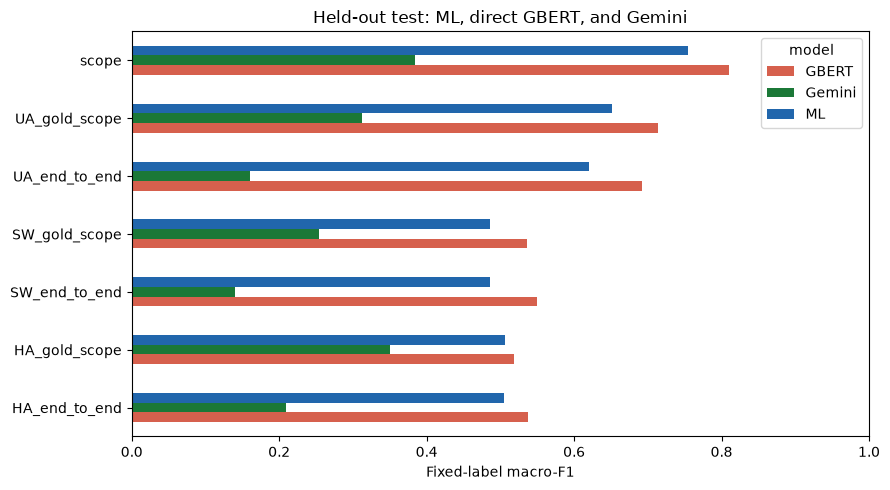

In [6]:
import matplotlib.pyplot as plt

if comparison_result is not None:
    comparison_summary = comparison_result['summary']
    display(comparison_summary.pivot(
        index='task', columns='model', values=['accuracy', 'macro_f1', 'supported_macro_f1', 'weighted_f1', 'n'],
    ).round(4))
    f1_comparison = comparison_summary.pivot(index='task', columns='model', values='macro_f1')
    for model_name in f1_comparison.columns:
        if model_name != 'ML':
            f1_comparison[f'{model_name}_minus_ML'] = f1_comparison[model_name] - f1_comparison['ML']
    print('Fixed-label macro-F1 differences versus ML; positive means the named model is higher:')
    display(f1_comparison.round(4))
    print('Per-class results: support=0 means this test split cannot measure that class recall.')
    display(comparison_result['per_class'].round(4))
    print('Timing includes model inference and configured Gemini pacing; this is not warmed model throughput.')
    display(comparison_result['timings'].round(3))
    plot_table = comparison_summary.pivot(index='task', columns='model', values='macro_f1')
    palette = {'ML': '#2166ac', 'GBERT': '#d6604d', 'Gemini': '#1b7837'}
    axis = plot_table.plot.barh(
        figsize=(9, 5),
        color=[palette[name] for name in plot_table.columns],
        xlim=(0, 1),
    )
    axis.set_xlabel('Fixed-label macro-F1')
    axis.set_ylabel('')
    axis.set_title('Held-out test: ML, direct GBERT, and Gemini')
    plt.tight_layout()
    plt.show()
else:
    print('Run the comparison cell before displaying results.')

In [ ]:
import json
from dataclasses import asdict
from datetime import datetime, timezone

if SAVE_COMPARISON:
    if comparison_result is None or comparison_ml_model is None:
        raise RuntimeError('Run the comparison before exporting aggregate metrics.')
    protected_value = os.getenv('PREBI_DATA_ROOT')
    if not protected_value:
        raise RuntimeError('Set PREBI_DATA_ROOT to approved protected storage.')
    comparison_protected_root = Path(protected_value).expanduser().resolve()
    if comparison_protected_root == COMPARISON_ROOT or COMPARISON_ROOT in comparison_protected_root.parents:
        raise ValueError('Protected storage must be outside the source tree.')
    comparison_models_tag = '-vs-'.join(
        name.lower() for name in comparison_result['summary']['model'].drop_duplicates()
    )
    comparison_directory = comparison_protected_root / 'evaluation' / (
        comparison_models_tag + '-' + datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
    )
    comparison_directory.mkdir(parents=True, mode=0o700, exist_ok=False)
    for name in ('summary', 'per_class', 'timings'):
        destination = comparison_directory / f'{name}.csv'
        comparison_result[name].to_csv(destination, index=False)
        os.chmod(destination, 0o600)
    checkpoint_hashes = {}
    for name, path in comparison_gbert_model.checkpoints.items():
        with path.open('rb') as checkpoint_file:
            checkpoint_hashes[name] = hashlib.file_digest(checkpoint_file, 'sha256').hexdigest()
    provenance = {
        'split': 'test', 'candidate_rows': comparison_result['candidate_rows'],
        'unique_segments': int(comparison_result['unique_segments']),
        'documents': int(comparison_result['documents']),
        'ml_settings': asdict(comparison_ml_model.settings),
        'ml_dev_comparison': ml_dev_comparison,
        'gbert_settings': COMPARISON_CONFIG['classifier'], 'gbert_device': GBERT_DEVICE,
        'gbert_checkpoint_sha256': checkpoint_hashes,
        'gbert_training_split_provenance': gbert_training_provenance,
        'timing_policy': 'Head loading included; Gemini per-document pacing included; initialization reported separately',
        'split_sha256': {
            split: hashlib.sha256(
                (COMPARISON_SPLIT_DIR / f'provisional_{split}_modeling_wide.csv').read_bytes()
            ).hexdigest() for split in ('train', 'dev', 'test')
        },
    }
    if comparison_gemini_model is not None:
        provenance['gemini'] = {
            'model_name': COMPARISON_CONFIG['generation']['model_name'],
            'temperature': COMPARISON_CONFIG['generation']['temperature'],
            'input_unit': 'complete_reflection',
            'minimum_request_interval_seconds': comparison_gemini_model.minimum_request_interval_seconds,
            'langsmith_tracing_enabled': comparison_gemini_model.enable_langsmith_tracing,
            'request_count': comparison_gemini_model.request_count,
        }
    if ML_MODEL_PATH is not None:
        with Path(ML_MODEL_PATH).expanduser().open('rb') as model_file:
            provenance['ml_model_sha256'] = hashlib.file_digest(model_file, 'sha256').hexdigest()
    metadata_path = comparison_directory / 'provenance.json'
    with metadata_path.open('x', encoding='utf-8') as metadata_file:
        json.dump(provenance, metadata_file, indent=2)
    os.chmod(metadata_path, 0o600)
    print('Aggregate comparison exported to approved protected storage; path withheld.')
else:
    print('Comparison export disabled; only aggregate metrics are held in memory.')

Comparison export disabled. Stop here for full model comparison; artifact-only evaluation below is independent.


In [7]:
import hashlib
import importlib

from reflection_assessment_feedback import segment_classification_hybrid

if 'hybrid_run_dir' in globals():
    previous_hybrid_run_dir = hybrid_run_dir
    previous_hybrid_test_predictions = hybrid_test_predictions.copy()

importlib.reload(segment_classification_hybrid)
assert 'Ausgangspunkt, kein Referenzlabel' in segment_classification_hybrid.HYBRID_CORRECTION_PROMPT
assert 'UA 1 vs. UA 2' in segment_classification_hybrid.HYBRID_CORRECTION_PROMPT
revised_hybrid_prompt_sha256 = hashlib.sha256(
    segment_classification_hybrid.HYBRID_CORRECTION_PROMPT.encode('utf-8')
).hexdigest()
print('Revised hybrid correction prompt loaded:', revised_hybrid_prompt_sha256)
print('The next hybrid inference cell starts a new protected run; previous artifacts remain unchanged.')

Revised hybrid correction prompt loaded: de85ba77793f92d6d207f8bdadceedbe419e73dcb57f97f15be7880a5bf2a22d
The next hybrid inference cell starts a new protected run; previous artifacts remain unchanged.


In [8]:
RUN_HYBRID_INFERENCE = True

if RUN_HYBRID_INFERENCE:
    import hashlib
    import json
    import os
    from datetime import datetime, timezone
    from pathlib import Path

    import pandas as pd
    import torch
    from dotenv import load_dotenv

    from reflection_assessment_feedback.experiment_config import load_experiment_config
    from reflection_assessment_feedback.segment_classification_hybrid import SegmentClassifierHybrid
    from reflection_assessment_feedback.segment_model_comparison import GBERTPredictor

    hybrid_root = Path.cwd().resolve()
    load_dotenv(hybrid_root / '.env', override=False)
    hybrid_config = load_experiment_config()
    hybrid_split_dir = hybrid_root / hybrid_config['paths']['provisional_split_directory']
    hybrid_checkpoint_dir = hybrid_root / hybrid_config['paths']['classifier_checkpoints']
    hybrid_protected_value = os.getenv('PREBI_DATA_ROOT')
    if not hybrid_protected_value:
        raise RuntimeError('Set PREBI_DATA_ROOT to approved protected storage.')
    hybrid_protected_root = Path(hybrid_protected_value).expanduser().resolve()
    if hybrid_protected_root == hybrid_root or hybrid_root in hybrid_protected_root.parents:
        raise ValueError('Protected storage must be outside the source tree.')
    hybrid_split_hashes = {
        f'{split}_{view}': hashlib.sha256(
            (hybrid_split_dir / f'provisional_{split}_{view}.csv').read_bytes()
        ).hexdigest()
        for split in ('train', 'dev', 'test') for view in ('scope', 'modeling_wide')
    }
    hybrid_checkpoint_hashes = {}
    for run_name in ('scope', 'direct-situationserfassung', 'direct-analyse', 'direct-konsequenzen'):
        metadata = json.loads((hybrid_checkpoint_dir / f'{run_name}.json').read_text())
        if metadata.get('split_sha256') != hybrid_split_hashes:
            raise ValueError('GBERT checkpoint training splits differ from the current export.')
        if metadata.get('selection_split') != 'dev' or metadata.get('test_used_for_training') is not False:
            raise ValueError('GBERT checkpoint provenance must confirm dev-only selection.')
        with (hybrid_checkpoint_dir / f'{run_name}.pt').open('rb') as checkpoint_file:
            checkpoint_hash = hashlib.file_digest(checkpoint_file, 'sha256').hexdigest()
        if checkpoint_hash != metadata.get('checkpoint_sha256'):
            raise ValueError('GBERT checkpoint hash differs from its metadata.')
        hybrid_checkpoint_hashes[run_name] = checkpoint_hash
    hybrid_test_rows = pd.read_csv(
        hybrid_split_dir / 'provisional_test_modeling_wide.csv',
        dtype={'candidate_id': str, 'document_id': str, 'segment_id': str},
    )
    if not hybrid_test_rows['split'].eq('test').all() or hybrid_test_rows['candidate_id'].duplicated().any():
        raise ValueError('Hybrid inference requires unique canonical test candidates.')
    hybrid_baseline = GBERTPredictor(
        hybrid_checkpoint_dir, hybrid_config['classifier'],
        device='mps' if torch.backends.mps.is_available() else 'cpu',
    )
    hybrid_generation = hybrid_config['generation']
    hybrid_classifier = SegmentClassifierHybrid.from_google_gemini(
        model_name=hybrid_generation['model_name'],
        temperature=hybrid_generation['temperature'],
        baseline_predictor=hybrid_baseline,
        enable_langsmith_tracing=hybrid_generation['enable_langsmith_tracing'],
        minimum_request_interval_seconds=hybrid_generation['minimum_request_interval_seconds'],
        rate_limit_state_path=hybrid_protected_root / '.rate_limits' / 'gemini.state',
    )
    hybrid_run_dir = hybrid_protected_root / 'evaluation' / (
        'hybrid-inference-' + datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
    )
    hybrid_run_dir.mkdir(parents=True, mode=0o700, exist_ok=False)
    hybrid_provenance = {
        'split': 'test', 'input_unit': 'complete_reflection', 'gold_scope_constraints': False,
        'model_name': hybrid_generation['model_name'],
        'temperature': hybrid_generation['temperature'],
        'langsmith_tracing_enabled': hybrid_generation['enable_langsmith_tracing'],
        'gbert_settings': hybrid_config['classifier'],
        'checkpoint_sha256': hybrid_checkpoint_hashes,
        'split_sha256': hybrid_split_hashes,
        'implementation_sha256': {
            filename: hashlib.sha256((hybrid_root / 'reflection_assessment_feedback' / filename).read_bytes()).hexdigest()
            for filename in ('segment_classification_hybrid.py', 'segment_classification_gemini.py')
        },
    }
    hybrid_input_columns = ['candidate_id', 'document_id', 'segment_id', 'segment_order', 'text']
    hybrid_predictions_parts = []
    hybrid_document_count = hybrid_test_rows['document_id'].nunique()
    print(f'Running hybrid inference for {hybrid_document_count} complete test reflections.', flush=True)
    for document_number, (_, document_rows) in enumerate(
        hybrid_test_rows.groupby('document_id', sort=True), start=1,
    ):
        document_rows = document_rows.reset_index(drop=True)
        corrected = hybrid_classifier.predict_frame(document_rows[hybrid_input_columns])
        prediction_rows = pd.concat([
            document_rows[['candidate_id', 'document_id', 'segment_id']], corrected,
        ], axis=1)
        package = {
            **hybrid_provenance,
            'predictions': prediction_rows.to_dict(orient='records'),
        }
        artifact_path = hybrid_run_dir / f'document-{document_number:03d}.json'
        descriptor = os.open(artifact_path, os.O_WRONLY | os.O_CREAT | os.O_EXCL, 0o600)
        with os.fdopen(descriptor, 'w', encoding='utf-8') as output_file:
            json.dump(package, output_file, ensure_ascii=False, indent=2)
        hybrid_predictions_parts.append(prediction_rows)
        print(f'Validated and saved hybrid reflection {document_number}/{hybrid_document_count}.', flush=True)
    hybrid_test_predictions = pd.concat(hybrid_predictions_parts, ignore_index=True)
    print(f'Hybrid inference complete: {len(hybrid_test_predictions)} candidate predictions; '
          f'{hybrid_classifier.request_count} provider requests. Protected paths and identifiers withheld.')
else:
    print('Hybrid provider inference is disabled. Set RUN_HYBRID_INFERENCE = True for the test reflections.')

Running hybrid inference for 24 complete test reflections.


/Users/quynguyen/Documents/CodingProjects/prebi_v1/.venv/lib/python3.14/site-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Validated and saved hybrid reflection 1/24.


/Users/quynguyen/Documents/CodingProjects/prebi_v1/.venv/lib/python3.14/site-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Validated and saved hybrid reflection 2/24.


...

Validated and saved hybrid reflection 22/24.


/Users/quynguyen/Documents/CodingProjects/prebi_v1/.venv/lib/python3.14/site-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Validated and saved hybrid reflection 23/24.


/Users/quynguyen/Documents/CodingProjects/prebi_v1/.venv/lib/python3.14/site-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Validated and saved hybrid reflection 24/24.
Hybrid inference complete: 905 candidate predictions; 24 provider requests. Protected paths and identifiers withheld.


In [2]:
import hashlib
import importlib
import json
import os
from dataclasses import asdict
from itertools import product
from pathlib import Path
from time import perf_counter

import pandas as pd
import torch
from dotenv import load_dotenv
from IPython.display import display

from reflection_assessment_feedback.experiment_config import load_experiment_config
from reflection_assessment_feedback.segment_classification_ml import MLSettings, SegmentClassifierML
from reflection_assessment_feedback import segment_model_comparison

importlib.reload(segment_model_comparison)
local_root = Path.cwd().resolve()
load_dotenv(local_root / '.env', override=False)
local_config = load_experiment_config()
local_split_dir = local_root / local_config['paths']['provisional_split_directory']
local_protected_root = Path(os.environ['PREBI_DATA_ROOT']).expanduser().resolve()
if local_protected_root == local_root or local_root in local_protected_root.parents:
    raise ValueError('Protected storage must be outside the source tree.')
if 'hybrid_run_dir' not in globals():
    raise RuntimeError('Set hybrid_run_dir to the saved hybrid inference directory before scoring.')
local_run_dir = Path(hybrid_run_dir).resolve()
if local_protected_root not in local_run_dir.parents:
    raise ValueError('Hybrid run must be in approved protected storage.')
local_packages = [json.loads(path.read_text()) for path in sorted(local_run_dir.glob('document-*.json'))]
if not local_packages:
    raise RuntimeError('The selected hybrid run contains no prediction artifacts.')
local_splits = {
    split: pd.read_csv(
        local_split_dir / f'provisional_{split}_modeling_wide.csv',
        dtype={'candidate_id': str, 'document_id': str, 'segment_id': str, 'author_id': str},
    ) for split in ('train', 'dev', 'test')
}
for left, right in (('train', 'dev'), ('train', 'test'), ('dev', 'test')):
    for column in ('document_id', 'segment_id', 'author_id'):
        if set(local_splits[left][column]) & set(local_splits[right][column]):
            raise ValueError('Train/dev/test group leakage detected.')
local_current_hashes = {
    f'{split}_{view}': hashlib.sha256(
        (local_split_dir / f'provisional_{split}_{view}.csv').read_bytes()
    ).hexdigest() for split in ('train', 'dev', 'test') for view in ('scope', 'modeling_wide')
}
local_checkpoint_dir = local_root / local_config['paths']['classifier_checkpoints']
local_checkpoint_hashes = {}
for name in ('scope', 'direct-situationserfassung', 'direct-analyse', 'direct-konsequenzen'):
    with (local_checkpoint_dir / f'{name}.pt').open('rb') as checkpoint_file:
        local_checkpoint_hashes[name] = hashlib.file_digest(checkpoint_file, 'sha256').hexdigest()
for package in local_packages:
    if package['split'] != 'test' or package['gold_scope_constraints'] is not False:
        raise ValueError('Comparison requires end-to-end held-out hybrid predictions.')
    if package['split_sha256'] != local_current_hashes or package['checkpoint_sha256'] != local_checkpoint_hashes:
        raise ValueError('Hybrid prediction provenance differs from current splits or GBERT checkpoints.')
    if package['gbert_settings'] != local_config['classifier']:
        raise ValueError('Hybrid baseline settings differ from the current GBERT settings.')
local_hybrid_predictions = pd.DataFrame([
    row for package in local_packages for row in package['predictions']
])
local_gold = local_splits['test']
if not local_gold['split'].eq('test').all() or local_gold['candidate_id'].duplicated().any():
    raise ValueError('Test rows must have unique candidate IDs.')
if local_hybrid_predictions['candidate_id'].duplicated().any():
    raise ValueError('Saved hybrid predictions contain duplicate candidates.')
if set(local_hybrid_predictions['candidate_id']) != set(local_gold['candidate_id']):
    raise ValueError('Saved hybrid predictions do not cover the full test split.')
local_hybrid_predictions = local_gold[['candidate_id', 'document_id', 'segment_id']].merge(
    local_hybrid_predictions, on=['candidate_id', 'document_id', 'segment_id'],
    how='left', validate='one_to_one', indicator=True,
)
if not local_hybrid_predictions['_merge'].eq('both').all():
    raise ValueError('Hybrid identifiers do not match the test candidate identities.')
print('Saved hybrid coverage and provenance verified. Selecting ML settings on dev only.', flush=True)
local_best_dev = float('-inf')
local_ml_selection = []
for architecture, estimator, regularization, class_weight in product(
    ('direct', 'hierarchical'), ('logistic', 'linear_svc'), (0.3, 1.0, 3.0), (None, 'balanced'),
):
    settings = MLSettings(
        architecture=architecture, estimator=estimator, regularization=regularization,
        class_weight=class_weight, seed=int(local_config['classifier']['seed']),
    )
    candidate = SegmentClassifierML(settings).fit(local_splits['train'])
    dev_score = candidate.evaluate(local_splits['dev'])['selection_macro_f1']
    local_ml_selection.append({**asdict(settings), 'dev_macro_f1': dev_score})
    if dev_score > local_best_dev:
        local_best_dev = dev_score
        local_ml_model = candidate
local_gbert_model = segment_model_comparison.GBERTPredictor(
    local_checkpoint_dir, local_config['classifier'],
    device='mps' if torch.backends.mps.is_available() else 'cpu',
)
local_prediction_columns = ['scope', 'SW', 'UA', 'HA']
local_prediction_frames = {'Hybrid': local_hybrid_predictions[local_prediction_columns]}
local_timings = []
for name, predictor in {'ML': local_ml_model, 'GBERT': local_gbert_model}.items():
    started = perf_counter()
    local_prediction_frames[name] = predictor.predict(local_gold['text'].tolist())
    local_timings.append({'model': name, 'end_to_end_seconds': perf_counter() - started})
local_metrics = {
    name: segment_model_comparison.score_predictions(local_gold, predictions)
    for name, predictions in local_prediction_frames.items()
}
saved_comparison_summary = pd.concat([
    metrics['summary'].assign(model=name) for name, metrics in local_metrics.items()
], ignore_index=True)
saved_comparison_per_class = pd.concat([
    metrics['per_class'].assign(model=name) for name, metrics in local_metrics.items()
], ignore_index=True)
print(f'End-to-end comparison: {len(local_gold)} candidates; no provider calls.', flush=True)
print('Standalone Gemini is unavailable: no complete saved test predictions were found.')
display(saved_comparison_summary.pivot(
    index='task', columns='model', values=['accuracy', 'macro_f1', 'supported_macro_f1', 'weighted_f1'],
).round(4))
print('Selected ML settings:', local_ml_model.settings)
for filename, data in (
    ('comparison-summary.csv', saved_comparison_summary),
    ('comparison-per-class.csv', saved_comparison_per_class),
):
    descriptor = os.open(local_run_dir / filename, os.O_WRONLY | os.O_CREAT | os.O_TRUNC, 0o600)
    with os.fdopen(descriptor, 'w') as output_file:
        data.to_csv(output_file, index=False)
local_report = {
    'split': 'test', 'candidate_rows': len(local_gold),
    'models': list(local_metrics), 'unavailable_models': ['Gemini'],
    'oracle_diagnostics': False, 'ml_settings': asdict(local_ml_model.settings),
    'ml_dev_selection': local_ml_selection, 'local_inference_timings': local_timings,
    'checkpoint_sha256': local_checkpoint_hashes, 'split_sha256': local_current_hashes,
    'summary': saved_comparison_summary.to_dict(orient='records'),
}
descriptor = os.open(local_run_dir / 'comparison-report.json', os.O_WRONLY | os.O_CREAT | os.O_TRUNC, 0o600)
with os.fdopen(descriptor, 'w') as output_file:
    json.dump(local_report, output_file, indent=2)
print('Aggregate comparison saved alongside the protected hybrid prediction artifacts.')

Saved hybrid coverage and provenance verified. Selecting ML settings on dev only.
End-to-end comparison: 905 candidates; no provider calls.
Standalone Gemini is unavailable: no complete saved test predictions were found.


accuracy                 macro_f1                  \
model            GBERT  Hybrid      ML    GBERT  Hybrid      ML   
task                                                              
HA_end_to_end   0.8884  0.8619  0.8530   0.5379  0.4886  0.5049   
SW_end_to_end   0.7768  0.6464  0.7127   0.5495  0.4504  0.4863   
UA_end_to_end   0.7215  0.6608  0.6818   0.6924  0.5467  0.6205   
scope           0.9768  0.9657  0.9591   0.8098  0.7527  0.7551   

              supported_macro_f1                 weighted_f1                  
model                      GBERT  Hybrid      ML       GBERT  Hybrid      ML  
task                                                                          
HA_end_to_end             0.5379  0.4886  0.5049      0.8819  0.8618  0.8566  
SW_end_to_end             0.6868  0.5630  0.6079      0.7741  0.6654  0.7207  
UA_end_to_end             0.6924  0.5467  0.6205      0.7261  0.6514  0.6811  
scope                     0.8098  0.7527  0.7551      0.9758  0.9665  0.9633

Selected ML settings: MLSettings(architecture='hierarchical', estimator='logistic', regularization=0.3, class_weight='balanced', minimum_text_characters=10, word_max_features=40000, char_max_features=60000, seed=20260929)
Aggregate comparison saved alongside the protected hybrid prediction artifacts.


In [9]:
import hashlib
import json
import os
from datetime import datetime, timezone

import pandas as pd
from IPython.display import display
from reflection_assessment_feedback.segment_model_comparison import score_predictions

required_variables = ['local_gold', 'local_prediction_frames', 'hybrid_run_dir',
                      'previous_hybrid_run_dir', 'standalone_run_dir', 'local_report']
if any(variable not in globals() for variable in required_variables):
    raise RuntimeError('Load the baseline comparison and both hybrid runs before revised evaluation.')
revised_test_hash = hashlib.sha256(
    (local_split_dir / 'provisional_test_modeling_wide.csv').read_bytes()
).hexdigest()
if revised_test_hash != local_current_hashes['test_modeling_wide']:
    raise ValueError('Test data changed since baseline inference.')
revised_identity_columns = ['candidate_id', 'document_id', 'segment_id']
revised_prediction_columns = ['scope', 'SW', 'UA', 'HA']

def load_aligned_evaluation_predictions(run_directory, *, hybrid):
    packages = [json.loads(path.read_text()) for path in sorted(run_directory.glob('document-*.json'))]
    if not packages:
        raise ValueError('Prediction run contains no document artifacts.')
    for package in packages:
        if package['split'] != 'test' or package['gold_scope_constraints'] is not False:
            raise ValueError('Expected end-to-end test predictions without gold-scope constraints.')
        if hybrid:
            if package['split_sha256'] != local_current_hashes:
                raise ValueError('Hybrid split provenance differs from baseline comparison.')
            if package['checkpoint_sha256'] != local_checkpoint_hashes:
                raise ValueError('Hybrid checkpoint provenance differs from baseline comparison.')
        elif package['test_split_sha256'] != revised_test_hash:
            raise ValueError('Standalone Gemini split provenance differs from baseline comparison.')
    predictions = pd.DataFrame([row for package in packages for row in package['predictions']])
    if predictions['candidate_id'].duplicated().any():
        raise ValueError('Prediction run contains duplicate candidates.')
    if set(predictions['candidate_id']) != set(local_gold['candidate_id']):
        raise ValueError('Prediction run does not cover every test candidate.')
    aligned = local_gold[revised_identity_columns].merge(
        predictions, on=revised_identity_columns, how='left', validate='one_to_one', indicator=True,
    )
    if not aligned['_merge'].eq('both').all():
        raise ValueError('Prediction identities differ from test gold.')
    return aligned[revised_prediction_columns].reset_index(drop=True)

revised_prediction_frames = {
    'ML': local_prediction_frames['ML'],
    'GBERT': local_prediction_frames['GBERT'],
    'Gemini': load_aligned_evaluation_predictions(standalone_run_dir, hybrid=False),
    'Hybrid previous': load_aligned_evaluation_predictions(previous_hybrid_run_dir, hybrid=True),
    'Hybrid revised': load_aligned_evaluation_predictions(hybrid_run_dir, hybrid=True),
}
revised_metrics = {
    model: score_predictions(local_gold, predictions)
    for model, predictions in revised_prediction_frames.items()
}
revised_comparison_summary = pd.concat([
    metrics['summary'].assign(model=model) for model, metrics in revised_metrics.items()
], ignore_index=True)
revised_comparison_per_class = pd.concat([
    metrics['per_class'].assign(model=model) for model, metrics in revised_metrics.items()
], ignore_index=True)
print(f'Revised end-to-end evaluation: {len(local_gold)} candidates; no model or provider calls.')
display(revised_comparison_summary.pivot(
    index='task', columns='model', values=['accuracy', 'macro_f1', 'supported_macro_f1', 'weighted_f1'],
).round(4))
revised_f1 = revised_comparison_summary.pivot(index='task', columns='model', values='macro_f1')
revised_f1['revised_minus_previous'] = revised_f1['Hybrid revised'] - revised_f1['Hybrid previous']
revised_f1['revised_minus_GBERT'] = revised_f1['Hybrid revised'] - revised_f1['GBERT']
display(revised_f1.round(4))
revised_export_stamp = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
for filename, frame in (
    ('summary', revised_comparison_summary), ('per-class', revised_comparison_per_class),
):
    descriptor = os.open(
        hybrid_run_dir / f'revised-comparison-{filename}-{revised_export_stamp}.csv',
        os.O_WRONLY | os.O_CREAT | os.O_EXCL, 0o600,
    )
    with os.fdopen(descriptor, 'w') as output_file:
        frame.to_csv(output_file, index=False)
revised_report = {
    'split': 'test', 'candidate_rows': len(local_gold), 'oracle_diagnostics': False,
    'hybrid_prompt_sha256': revised_hybrid_prompt_sha256,
    'previous_hybrid_run': previous_hybrid_run_dir.name,
    'revised_hybrid_run': hybrid_run_dir.name, 'standalone_run': standalone_run_dir.name,
    'baseline_comparison_provenance': local_report,
    'summary': revised_comparison_summary.to_dict(orient='records'),
}
descriptor = os.open(
    hybrid_run_dir / f'revised-comparison-report-{revised_export_stamp}.json',
    os.O_WRONLY | os.O_CREAT | os.O_EXCL, 0o600,
)
with os.fdopen(descriptor, 'w') as output_file:
    json.dump(revised_report, output_file, indent=2)
print('Updated aggregate comparison saved beside the revised hybrid artifacts; previous reports unchanged.')
print('The revised prompt follows exploratory analysis of this test cohort; treat this run as '
      'post-hoc exploratory evaluation, not a fresh untouched held-out validation.')

Revised end-to-end evaluation: 905 candidates; no model or provider calls.


accuracy                                                 \
model            GBERT  Gemini Hybrid previous Hybrid revised      ML   
task                                                                    
HA_end_to_end   0.8884  0.4254          0.8619         0.8862  0.8530   
SW_end_to_end   0.7768  0.2343          0.6464         0.6564  0.7127   
UA_end_to_end   0.7215  0.3072          0.6608         0.6884  0.6818   
scope           0.9768  0.5238          0.9657         0.9768  0.9591   

              macro_f1                                                 \
model            GBERT  Gemini Hybrid previous Hybrid revised      ML   
task                                                                    
HA_end_to_end   0.5379  0.2564          0.4886         0.5460  0.5049   
SW_end_to_end   0.5495  0.1570          0.4504         0.4736  0.4863   
UA_end_to_end   0.6924  0.1813          0.5467         0.6246  0.6205   
scope           0.8098  0.3882          0.7527         0.8098  0.7551   

              supported_macro_f1                                         \
model                      GBERT  Gemini Hybrid previous Hybrid revised   
task                                                                      
HA_end_to_end             0.5379  0.2564          0.4886         0.5460   
SW_end_to_end             0.6868  0.1962          0.5630         0.5921   
UA_end_to_end             0.6924  0.1813          0.5467         0.6246   
scope                     0.8098  0.3882          0.7527         0.8098   

                      weighted_f1                                         \
model              ML       GBERT  Gemini Hybrid previous Hybrid revised   
task                                                                       
HA_end_to_end  0.5049      0.8819  0.5195          0.8618         0.8844   
SW_end_to_end  0.6079      0.7741  0.2651          0.6654         0.6839   
UA_end_to_end  0.6205      0.7261  0.3623          0.6514         0.6856   
scope          0.7551      0.9758  0.6565          0.9665         0.9758   

                       
model              ML  
task                   
HA_end_to_end  0.8566  
SW_end_to_end  0.7207  
UA_end_to_end  0.6811  
scope          0.9633

model,GBERT,Gemini,Hybrid previous,Hybrid revised,ML,revised_minus_previous,revised_minus_GBERT
task,,,,,,,
HA_end_to_end,0.5379,0.2564,0.4886,0.5460,0.5049,0.0574,0.0082
SW_end_to_end,0.5495,0.1570,0.4504,0.4736,0.4863,0.0232,-0.0758
UA_end_to_end,0.6924,0.1813,0.5467,0.6246,0.6205,0.0779,-0.0678
scope,0.8098,0.3882,0.7527,0.8098,0.7551,0.0571,0.0000


Updated aggregate comparison saved beside the revised hybrid artifacts; previous reports unchanged.
The revised prompt follows exploratory analysis of this test cohort; treat this run as post-hoc exploratory evaluation, not a fresh untouched held-out validation.


In [3]:
RUN_STANDALONE_GEMINI_INFERENCE = True

if RUN_STANDALONE_GEMINI_INFERENCE:
    import hashlib
    import json
    import os
    from datetime import datetime, timezone
    from pathlib import Path

    import pandas as pd
    from dotenv import load_dotenv
    from IPython.display import display

    from reflection_assessment_feedback.experiment_config import load_experiment_config
    from reflection_assessment_feedback.segment_classification_gemini import SegmentClassifierGemini
    from reflection_assessment_feedback.segment_model_comparison import score_predictions

    standalone_root = Path.cwd().resolve()
    load_dotenv(standalone_root / '.env', override=False)
    standalone_config = load_experiment_config()
    standalone_protected_value = os.getenv('PREBI_DATA_ROOT')
    if not standalone_protected_value:
        raise RuntimeError('Set PREBI_DATA_ROOT to approved protected storage.')
    standalone_protected_root = Path(standalone_protected_value).expanduser().resolve()
    if standalone_protected_root == standalone_root or standalone_root in standalone_protected_root.parents:
        raise ValueError('Protected storage must be outside the source tree.')
    standalone_test_path = (
        standalone_root / standalone_config['paths']['provisional_split_directory']
        / 'provisional_test_modeling_wide.csv'
    )
    standalone_test_hash = hashlib.sha256(standalone_test_path.read_bytes()).hexdigest()
    standalone_gold = pd.read_csv(
        standalone_test_path,
        dtype={'candidate_id': str, 'document_id': str, 'segment_id': str},
    )
    if not standalone_gold['split'].eq('test').all() or standalone_gold['candidate_id'].duplicated().any():
        raise ValueError('Standalone Gemini requires unique canonical test candidates.')
    standalone_generation = standalone_config['generation']
    standalone_classifier = SegmentClassifierGemini.from_google_gemini(
        model_name=standalone_generation['model_name'],
        temperature=standalone_generation['temperature'],
        enable_langsmith_tracing=standalone_generation['enable_langsmith_tracing'],
        minimum_request_interval_seconds=standalone_generation['minimum_request_interval_seconds'],
        rate_limit_state_path=standalone_protected_root / '.rate_limits' / 'gemini.state',
    )
    standalone_run_dir = standalone_protected_root / 'evaluation' / (
        'gemini-inference-' + datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
    )
    standalone_run_dir.mkdir(parents=True, mode=0o700, exist_ok=False)
    standalone_provenance = {
        'split': 'test', 'input_unit': 'complete_reflection',
        'classifier_backend': 'standalone_gemini', 'gold_scope_constraints': False,
        'model_name': standalone_generation['model_name'],
        'temperature': standalone_generation['temperature'],
        'langsmith_tracing_enabled': standalone_generation['enable_langsmith_tracing'],
        'test_split_sha256': standalone_test_hash,
        'rubric_sha256': hashlib.sha256(standalone_classifier.rubric.model_dump_json().encode()).hexdigest(),
        'implementation_sha256': hashlib.sha256(
            (standalone_root / 'reflection_assessment_feedback' / 'segment_classification_gemini.py').read_bytes()
        ).hexdigest(),
    }
    standalone_input_columns = ['candidate_id', 'document_id', 'segment_id', 'segment_order', 'text']
    standalone_prediction_parts = []
    standalone_document_count = standalone_gold['document_id'].nunique()
    print(f'Running standalone Gemini for {standalone_document_count} complete test reflections.', flush=True)
    for standalone_document_number, (_, standalone_document_rows) in enumerate(
        standalone_gold.groupby('document_id', sort=True), start=1,
    ):
        standalone_document_rows = standalone_document_rows.reset_index(drop=True)
        standalone_corrected = standalone_classifier.predict_frame(
            standalone_document_rows[standalone_input_columns]
        )
        standalone_rows = pd.concat([
            standalone_document_rows[['candidate_id', 'document_id', 'segment_id']], standalone_corrected,
        ], axis=1)
        standalone_package = {
            **standalone_provenance, 'predictions': standalone_rows.to_dict(orient='records'),
        }
        standalone_path = standalone_run_dir / f'document-{standalone_document_number:03d}.json'
        standalone_descriptor = os.open(standalone_path, os.O_WRONLY | os.O_CREAT | os.O_EXCL, 0o600)
        with os.fdopen(standalone_descriptor, 'w', encoding='utf-8') as standalone_output:
            json.dump(standalone_package, standalone_output, ensure_ascii=False, indent=2)
        standalone_prediction_parts.append(standalone_rows)
        print(f'Validated and saved standalone reflection {standalone_document_number}/{standalone_document_count}.', flush=True)
    standalone_test_predictions = pd.concat(standalone_prediction_parts, ignore_index=True)
    if standalone_test_predictions['candidate_id'].duplicated().any():
        raise ValueError('Standalone predictions contain duplicate candidates.')
    standalone_aligned = standalone_gold[['candidate_id', 'document_id', 'segment_id']].merge(
        standalone_test_predictions, on=['candidate_id', 'document_id', 'segment_id'],
        how='left', validate='one_to_one', indicator=True,
    )
    if not standalone_aligned['_merge'].eq('both').all() or len(standalone_aligned) != len(standalone_test_predictions):
        raise ValueError('Standalone predictions must cover every test candidate exactly once.')
    standalone_metrics = score_predictions(standalone_gold, standalone_aligned[['scope', 'SW', 'UA', 'HA']])
    standalone_summary = standalone_metrics['summary'].assign(model='Gemini')
    standalone_per_class = standalone_metrics['per_class'].assign(model='Gemini')
    if 'saved_comparison_summary' in globals() and 'local_current_hashes' in globals():
        if local_current_hashes['test_modeling_wide'] != standalone_test_hash:
            raise ValueError('Previous comparison used a different test split.')
        four_model_summary = pd.concat([
            saved_comparison_summary.loc[saved_comparison_summary['model'].ne('Gemini')],
            standalone_summary,
        ], ignore_index=True)
        four_model_per_class = pd.concat([
            saved_comparison_per_class.loc[saved_comparison_per_class['model'].ne('Gemini')],
            standalone_per_class,
        ], ignore_index=True)
    else:
        four_model_summary = standalone_summary
        four_model_per_class = standalone_per_class
    print(f'Standalone inference complete: {len(standalone_test_predictions)} candidates; '
          f'{standalone_classifier.request_count} provider requests.', flush=True)
    display(four_model_summary.pivot(
        index='task', columns='model', values=['accuracy', 'macro_f1', 'supported_macro_f1', 'weighted_f1'],
    ).round(4))
    for standalone_filename, standalone_data in (
        ('comparison-summary.csv', four_model_summary),
        ('comparison-per-class.csv', four_model_per_class),
    ):
        standalone_descriptor = os.open(
            standalone_run_dir / standalone_filename, os.O_WRONLY | os.O_CREAT | os.O_EXCL, 0o600,
        )
        with os.fdopen(standalone_descriptor, 'w') as standalone_output:
            standalone_data.to_csv(standalone_output, index=False)
    standalone_report = {
        **standalone_provenance, 'request_count': standalone_classifier.request_count,
        'models': four_model_summary['model'].drop_duplicates().tolist(),
        'candidate_rows': len(standalone_gold),
        'summary': four_model_summary.to_dict(orient='records'),
    }
    if 'local_report' in globals() and local_report['split_sha256']['test_modeling_wide'] == standalone_test_hash:
        standalone_report['baseline_comparison_provenance'] = local_report
    standalone_descriptor = os.open(
        standalone_run_dir / 'comparison-report.json', os.O_WRONLY | os.O_CREAT | os.O_EXCL, 0o600,
    )
    with os.fdopen(standalone_descriptor, 'w') as standalone_output:
        json.dump(standalone_report, standalone_output, indent=2)
    print('Standalone predictions and comparison saved in protected storage; paths and identifiers withheld.')
else:
    print('Standalone Gemini inference disabled.')

Running standalone Gemini for 24 complete test reflections.


/Users/quynguyen/Documents/CodingProjects/prebi_v1/.venv/lib/python3.14/site-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Validated and saved standalone reflection 1/24.


/Users/quynguyen/Documents/CodingProjects/prebi_v1/.venv/lib/python3.14/site-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Validated and saved standalone reflection 2/24.


...

Validated and saved standalone reflection 13/24.


/Users/quynguyen/Documents/CodingProjects/prebi_v1/.venv/lib/python3.14/site-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Validated and saved standalone reflection 14/24.


/Users/quynguyen/Documents/CodingProjects/prebi_v1/.venv/lib/python3.14/site-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


OutputParserException: Failed to parse GeminiReflectionPrediction from completion {"predictions": [{"scope": "out_of_scope", "component_bands": {"SW": "N", "UA": "N", "HA": "N"}, "index": 0}, {"scope": "out_of_scope", "component_bands": {"SW": "N", "UA": "N", "HA": "N"}, "index": 1}, {"scope": "out_of_scope", "component_bands": {"SW": "N", "UA": "N", "HA": "N"}, "index": 2}, {"scope": "out_of_scope", "component_bands": {"SW": "N", "UA": "N", "HA": "N"}, "index": 3}, {"scope": "out_of_scope", "component_bands": {"SW": "N", "UA": "N", "HA": "N"}, "index": 4}, {"scope": "out_of_scope", "component_bands": {"SW": "N", "UA": "N", "HA": "N"}, "index": 5}, {"scope": "out_of_scope", "component_bands": {"SW": "N", "UA": "N", "HA": "N"}, "index": 6}, {"scope": "in_scope", "component_bands": {"SW": "2", "UA": "N", "HA": "N"}, "index": 7}, {"scope": "in_scope", "component_bands": {"SW": "2", "UA": "N", "HA": "N"}, "index": 8}, {"scope": "in_scope", "component_bands": {"SW": "2", "UA": "N", "HA": "N

In [4]:
import json
import os

import pandas as pd
from IPython.display import display
from langchain_core.exceptions import OutputParserException
from pydantic import ValidationError

from reflection_assessment_feedback.segment_model_comparison import score_predictions

if 'standalone_run_dir' not in globals() or 'standalone_classifier' not in globals():
    raise RuntimeError('Initialize the standalone inference cell before resuming.')
standalone_prediction_parts = []
for standalone_document_number, (_, standalone_document_rows) in enumerate(
    standalone_gold.groupby('document_id', sort=True), start=1,
):
    standalone_document_rows = standalone_document_rows.reset_index(drop=True)
    standalone_path = standalone_run_dir / f'document-{standalone_document_number:03d}.json'
    if standalone_path.exists():
        standalone_package = json.loads(standalone_path.read_text())
        if any(standalone_package.get(key) != value for key, value in standalone_provenance.items()):
            raise ValueError('Saved standalone prediction provenance does not match this run.')
        standalone_rows = pd.DataFrame(standalone_package['predictions'])
        if set(standalone_rows['candidate_id']) != set(standalone_document_rows['candidate_id']):
            raise ValueError('Saved standalone artifact has different candidate coverage.')
    else:
        for standalone_attempt in range(1, 4):
            try:
                standalone_corrected = standalone_classifier.predict_frame(
                    standalone_document_rows[standalone_input_columns]
                )
                break
            except (OutputParserException, ValidationError, ValueError):
                if standalone_attempt == 3:
                    raise
                print(f'Reflection {standalone_document_number}: invalid structured output; '
                      f'retrying unchanged prompt ({standalone_attempt}/3).', flush=True)
        standalone_rows = pd.concat([
            standalone_document_rows[['candidate_id', 'document_id', 'segment_id']], standalone_corrected,
        ], axis=1)
        standalone_package = {
            **standalone_provenance, 'predictions': standalone_rows.to_dict(orient='records'),
        }
        standalone_descriptor = os.open(standalone_path, os.O_WRONLY | os.O_CREAT | os.O_EXCL, 0o600)
        with os.fdopen(standalone_descriptor, 'w', encoding='utf-8') as standalone_output:
            json.dump(standalone_package, standalone_output, ensure_ascii=False, indent=2)
    standalone_prediction_parts.append(standalone_rows)
    print(f'Standalone artifact ready {standalone_document_number}/{standalone_document_count}.', flush=True)
standalone_test_predictions = pd.concat(standalone_prediction_parts, ignore_index=True)
if standalone_test_predictions['candidate_id'].duplicated().any():
    raise ValueError('Standalone predictions contain duplicate candidates.')
standalone_aligned = standalone_gold[['candidate_id', 'document_id', 'segment_id']].merge(
    standalone_test_predictions, on=['candidate_id', 'document_id', 'segment_id'],
    how='left', validate='one_to_one', indicator=True,
)
if not standalone_aligned['_merge'].eq('both').all() or len(standalone_aligned) != len(standalone_test_predictions):
    raise ValueError('Standalone predictions must cover every test candidate exactly once.')
standalone_metrics = score_predictions(standalone_gold, standalone_aligned[['scope', 'SW', 'UA', 'HA']])
standalone_summary = standalone_metrics['summary'].assign(model='Gemini')
standalone_per_class = standalone_metrics['per_class'].assign(model='Gemini')
if 'saved_comparison_summary' in globals() and 'local_current_hashes' in globals():
    if local_current_hashes['test_modeling_wide'] != standalone_test_hash:
        raise ValueError('Previous comparison used a different test split.')
    four_model_summary = pd.concat([
        saved_comparison_summary.loc[saved_comparison_summary['model'].ne('Gemini')], standalone_summary,
    ], ignore_index=True)
    four_model_per_class = pd.concat([
        saved_comparison_per_class.loc[saved_comparison_per_class['model'].ne('Gemini')], standalone_per_class,
    ], ignore_index=True)
else:
    four_model_summary = standalone_summary
    four_model_per_class = standalone_per_class
print(f'Standalone inference complete: {len(standalone_test_predictions)} candidates; '
      f'{standalone_classifier.request_count} provider attempts, including rejected responses.', flush=True)
display(four_model_summary.pivot(
    index='task', columns='model', values=['accuracy', 'macro_f1', 'supported_macro_f1', 'weighted_f1'],
).round(4))
for standalone_filename, standalone_data in (
    ('comparison-summary.csv', four_model_summary), ('comparison-per-class.csv', four_model_per_class),
):
    standalone_descriptor = os.open(
        standalone_run_dir / standalone_filename, os.O_WRONLY | os.O_CREAT | os.O_EXCL, 0o600,
    )
    with os.fdopen(standalone_descriptor, 'w') as standalone_output:
        standalone_data.to_csv(standalone_output, index=False)
standalone_report = {
    **standalone_provenance, 'request_count': standalone_classifier.request_count,
    'retry_policy': 'Up to three attempts per document with identical prompt; invalid outputs rejected',
    'models': four_model_summary['model'].drop_duplicates().tolist(),
    'candidate_rows': len(standalone_gold), 'summary': four_model_summary.to_dict(orient='records'),
}
if 'local_report' in globals() and local_report['split_sha256']['test_modeling_wide'] == standalone_test_hash:
    standalone_report['baseline_comparison_provenance'] = local_report
standalone_descriptor = os.open(
    standalone_run_dir / 'comparison-report.json', os.O_WRONLY | os.O_CREAT | os.O_EXCL, 0o600,
)
with os.fdopen(standalone_descriptor, 'w') as standalone_output:
    json.dump(standalone_report, standalone_output, indent=2)
print('Validated standalone predictions and comparison saved in protected storage.')

Standalone artifact ready 1/24.
Standalone artifact ready 2/24.
Standalone artifact ready 3/24.
Standalone artifact ready 4/24.
Standalone artifact ready 5/24.
Standalone artifact ready 6/24.
Standalone artifact ready 7/24.
Standalone artifact ready 8/24.
Standalone artifact ready 9/24.
Standalone artifact ready 10/24.
Standalone artifact ready 11/24.
Standalone artifact ready 12/24.
Standalone artifact ready 13/24.
Standalone artifact ready 14/24.


/Users/quynguyen/Documents/CodingProjects/prebi_v1/.venv/lib/python3.14/site-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Standalone artifact ready 15/24.


/Users/quynguyen/Documents/CodingProjects/prebi_v1/.venv/lib/python3.14/site-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Standalone artifact ready 16/24.


...

Standalone artifact ready 23/24.


/Users/quynguyen/Documents/CodingProjects/prebi_v1/.venv/lib/python3.14/site-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Standalone artifact ready 24/24.
Standalone inference complete: 905 candidates; 25 provider attempts, including rejected responses.


accuracy                         macro_f1                  \
model            GBERT  Gemini  Hybrid      ML    GBERT  Gemini  Hybrid   
task                                                                      
HA_end_to_end   0.8884  0.4254  0.8619  0.8530   0.5379  0.2564  0.4886   
SW_end_to_end   0.7768  0.2343  0.6464  0.7127   0.5495  0.1570  0.4504   
UA_end_to_end   0.7215  0.3072  0.6608  0.6818   0.6924  0.1813  0.5467   
scope           0.9768  0.5238  0.9657  0.9591   0.8098  0.3882  0.7527   

                      supported_macro_f1                         weighted_f1  \
model              ML              GBERT  Gemini  Hybrid      ML       GBERT   
task                                                                           
HA_end_to_end  0.5049             0.5379  0.2564  0.4886  0.5049      0.8819   
SW_end_to_end  0.4863             0.6868  0.1962  0.5630  0.6079      0.7741   
UA_end_to_end  0.6205             0.6924  0.1813  0.5467  0.6205      0.7261   
scope          0.7551             0.8098  0.3882  0.7527  0.7551      0.9758   

                                       
model          Gemini  Hybrid      ML  
task                                   
HA_end_to_end  0.5195  0.8618  0.8566  
SW_end_to_end  0.2651  0.6654  0.7207  
UA_end_to_end  0.3623  0.6514  0.6811  
scope          0.6565  0.9665  0.9633

Validated standalone predictions and comparison saved in protected storage.


In [5]:
import json
from pathlib import Path

import pandas as pd
from reflection_assessment_feedback.models import IntermediateAnalysis
from reflection_assessment_feedback.experiment_config import experiment_config_sha256

if 'local_prediction_frames' not in globals() or 'GBERT' not in local_prediction_frames:
    raise RuntimeError('Run the local comparison before auditing in-memory GBERT predictions.')
audit_labels = ['scope', 'SW', 'UA', 'HA']
audit_keys = ['document_id', 'segment_id']
audit_memory = pd.concat([
    local_gold[audit_keys].astype(str).reset_index(drop=True),
    local_prediction_frames['GBERT'][audit_labels].reset_index(drop=True),
], axis=1)
if audit_memory.groupby(audit_keys)[audit_labels].nunique().gt(1).any().any():
    raise ValueError('In-memory GBERT disagrees across candidate copies of a segment.')
audit_memory = audit_memory.drop_duplicates(audit_keys)
audit_g2_rows = []
audit_g2_config_hashes = set()
for audit_path in sorted((local_protected_root / 'g2' / 'predictions').glob('predicted-analysis-*.json')):
    audit_package = json.loads(audit_path.read_text())
    audit_analysis = IntermediateAnalysis.model_validate(audit_package['analysis'])
    if audit_analysis.source != 'predicted':
        raise ValueError('G2 artifact is not predicted analysis.')
    audit_g2_config_hashes.add(audit_package.get('experiment_config_sha256'))
    for audit_segment in audit_analysis.segments:
        audit_g2_rows.append({
            'document_id': str(audit_package['document_id']),
            'segment_id': audit_segment.segment_id,
            'scope': int(audit_segment.scope == 'in_scope'),
            **audit_segment.component_bands,
        })
audit_g2 = pd.DataFrame(audit_g2_rows)
if audit_g2.duplicated(audit_keys).any():
    raise ValueError('G2 artifacts contain duplicate document/segment keys.')
audit_join = audit_memory.merge(
    audit_g2, on=audit_keys, how='outer', validate='one_to_one',
    suffixes=('_memory', '_g2'), indicator=True,
)
audit_shared = audit_join.loc[audit_join['_merge'].eq('both')].copy()
audit_differences = pd.DataFrame({
    label: audit_shared[f'{label}_memory'].ne(audit_shared[f'{label}_g2'])
    for label in audit_labels
}, index=audit_shared.index)
audit_document_188 = audit_shared['document_id'].eq('188')
gbert_g2_audit = {
    'memory_documents': int(audit_memory.document_id.nunique()),
    'g2_documents': int(audit_g2.document_id.nunique()),
    'shared_documents': int(audit_shared.document_id.nunique()),
    'shared_segments': len(audit_shared),
    'segments_only_in_memory': int(audit_join['_merge'].eq('left_only').sum()),
    'segments_only_in_g2': int(audit_join['_merge'].eq('right_only').sum()),
    'shared_segments_with_any_difference': int(audit_differences.any(axis=1).sum()),
    'differences_by_label': {label: int(audit_differences[label].sum()) for label in audit_labels},
    'document_188_shared_segments': int(audit_document_188.sum()),
    'document_188_differences_by_label': {
        label: int(audit_differences.loc[audit_document_188, label].sum()) for label in audit_labels
    },
    'g2_config_hashes_match_current': audit_g2_config_hashes == {experiment_config_sha256()},
    'memory_checkpoint_run': local_gbert_model.checkpoint_directory.name,
}
print(json.dumps(gbert_g2_audit, indent=2))

{
  "memory_documents": 24,
  "g2_documents": 22,
  "shared_documents": 22,
  "shared_segments": 831,
  "segments_only_in_memory": 72,
  "segments_only_in_g2": 0,
  "shared_segments_with_any_difference": 0,
  "differences_by_label": {
    "scope": 0,
    "SW": 0,
    "UA": 0,
    "HA": 0
  },
  "document_188_shared_segments": 37,
  "document_188_differences_by_label": {
    "scope": 0,
    "SW": 0,
    "UA": 0,
    "HA": 0
  },
  "g2_config_hashes_match_current": false,
  "memory_checkpoint_run": "retrain-20261003T125604532027Z"
}


In [6]:
import hashlib
import json
import os
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

from reflection_assessment_feedback.data import TARGET_COLUMNS
from reflection_assessment_feedback.development_cohorts import load_author_document_group
from reflection_assessment_feedback.segment_model_comparison import score_predictions

if 'local_gold' not in globals() or 'local_prediction_frames' not in globals():
    raise RuntimeError('Run the local GBERT comparison before playground error analysis.')
playground_anchor = str(local_config['dataset']['exploratory_document_id'])
playground_group = load_author_document_group(
    local_split_dir / 'provisional_split_manifest.csv', playground_anchor,
)
playground_document_ids = set(playground_group['document_id'])
if len(local_gold) != len(local_prediction_frames['GBERT']):
    raise ValueError('In-memory GBERT candidate alignment is incomplete.')
playground_all_predictions = pd.concat([
    local_gold[['candidate_id', 'document_id', 'segment_id']].astype(str).reset_index(drop=True),
    local_prediction_frames['GBERT'][['scope', *TARGET_COLUMNS]].reset_index(drop=True),
], axis=1)
playground_current_gold = pd.read_csv(
    local_split_dir / 'provisional_test_modeling_wide.csv',
    dtype={'candidate_id': str, 'document_id': str, 'segment_id': str, 'author_id': str},
)
playground_test_hash = hashlib.sha256(
    (local_split_dir / 'provisional_test_modeling_wide.csv').read_bytes()
).hexdigest()
if playground_test_hash != local_current_hashes['test_modeling_wide']:
    raise ValueError('Test data changed since in-memory GBERT inference.')
playground_gold = playground_current_gold.loc[
    playground_current_gold['document_id'].isin(playground_document_ids)
].copy().reset_index(drop=True)
if set(playground_gold['document_id']) != playground_document_ids:
    raise ValueError('Canonical test export does not cover every playground document.')
playground_joined = playground_gold.merge(
    playground_all_predictions.rename(columns={
        'scope': 'predicted_scope', **{dimension: f'predicted_{dimension}' for dimension in TARGET_COLUMNS},
    }),
    on=['candidate_id', 'document_id', 'segment_id'],
    how='left', validate='one_to_one', indicator=True,
)
if not playground_joined['_merge'].eq('both').all():
    raise ValueError('Missing GBERT predictions for playground candidates.')
playground_joined = playground_joined.drop(columns='_merge')
playground_predictions = playground_joined[['predicted_scope', *[
    f'predicted_{dimension}' for dimension in TARGET_COLUMNS
]]].rename(columns={
    'predicted_scope': 'scope', **{f'predicted_{dimension}': dimension for dimension in TARGET_COLUMNS},
})
playground_metrics = score_predictions(playground_gold, playground_predictions)
playground_review = playground_joined.copy()
playground_review['scope_error'] = playground_review['scope_target'].ne(playground_review['predicted_scope'])
playground_review['scope_error_type'] = np.select([
    playground_review['scope_target'].eq(1) & playground_review['predicted_scope'].eq(0),
    playground_review['scope_target'].eq(0) & playground_review['predicted_scope'].eq(1),
], ['scope_false_negative', 'scope_false_positive'], default='correct')
playground_error_parts = []
for dimension, target in TARGET_COLUMNS.items():
    expected = pd.Series('N', index=playground_review.index)
    in_scope = playground_review['scope_target'].eq(1)
    expected.loc[in_scope] = pd.to_numeric(
        playground_review.loc[in_scope, target], errors='raise',
    ).astype(int).astype(str)
    predicted = playground_review[f'predicted_{dimension}'].astype(str)
    error_type = pd.Series('correct', index=playground_review.index)
    mismatch = expected.ne(predicted)
    error_type.loc[mismatch & playground_review['scope_error']] = playground_review.loc[
        mismatch & playground_review['scope_error'], 'scope_error_type'
    ]
    routed = in_scope & playground_review['predicted_scope'].eq(1)
    error_type.loc[routed & expected.eq('0') & predicted.ne('0')] = 'dimension_false_positive'
    error_type.loc[routed & expected.ne('0') & predicted.eq('0')] = 'dimension_false_negative'
    error_type.loc[routed & expected.ne('0') & predicted.ne('0') & mismatch] = 'performance_band_mismatch'
    playground_review[f'gold_{dimension}'] = expected
    playground_review[f'{dimension}_error'] = mismatch
    playground_review[f'{dimension}_error_type'] = error_type
    playground_error_parts.append(pd.DataFrame({
        'document_id': playground_review['document_id'],
        'candidate_id': playground_review['candidate_id'],
        'segment_id': playground_review['segment_id'],
        'dimension': dimension, 'gold_label': expected,
        'predicted_label': predicted, 'error_type': error_type,
    }))
playground_dimension_decisions = pd.concat(playground_error_parts, ignore_index=True)
playground_review['any_error'] = playground_review[['scope_error', *[
    f'{dimension}_error' for dimension in TARGET_COLUMNS
]]].any(axis=1)
playground_error_counts = playground_dimension_decisions.groupby(
    ['dimension', 'error_type'], sort=True,
).size().rename('candidate_decisions').reset_index()
playground_scope_counts = playground_review.groupby('scope_error_type').size().rename('candidates').reset_index()
playground_document_summary = []
for document_number, (document_id, document_rows) in enumerate(
    playground_review.groupby('document_id', sort=True), start=1,
):
    playground_document_summary.append({
        'document': f'Playground {document_number}',
        'candidate_rows': len(document_rows),
        'unique_segments': document_rows['segment_id'].nunique(),
        'scope_errors': int(document_rows['scope_error'].sum()),
        **{f'{dimension}_errors': int(document_rows[f'{dimension}_error'].sum()) for dimension in TARGET_COLUMNS},
        'candidates_with_any_error': int(document_rows['any_error'].sum()),
        'segments_with_any_candidate_error': document_rows.loc[document_rows['any_error'], 'segment_id'].nunique(),
    })
playground_document_summary = pd.DataFrame(playground_document_summary)
print(f'Playground GBERT error analysis: {len(playground_document_ids)} documents, '
      f'{len(playground_review)} candidate rows, '
      f'{playground_review.drop_duplicates(["document_id", "segment_id"]).shape[0]} unique segments. No model calls.')
display(playground_document_summary)
display(playground_metrics['summary'].round(4))
display(playground_scope_counts)
display(playground_error_counts)
print('Alternative candidate annotations are retained. Scope errors propagate to component labels; '
      'dimension errors compare absence (0) with presence (1-3), and band errors compare positive labels. '
      'This exploratory test cohort must not be used for tuning reported test models.')
playground_protected_root = local_protected_root.resolve()
if playground_protected_root == local_root or local_root in playground_protected_root.parents:
    raise ValueError('Protected storage must be outside the source tree.')
playground_error_dir = playground_protected_root / 'evaluation' / (
    'playground-gbert-errors-' + datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
)
playground_error_dir.mkdir(parents=True, mode=0o700, exist_ok=False)
playground_review = playground_review.sort_values(['document_id', 'segment_order', 'candidate_id'])
for filename, frame in (
    ('candidate-review.csv', playground_review),
    ('error-candidates.csv', playground_review.loc[playground_review['any_error']]),
    ('dimension-decisions.csv', playground_dimension_decisions),
    ('document-summary.csv', playground_document_summary),
    ('task-metrics.csv', playground_metrics['summary']),
    ('per-class-metrics.csv', playground_metrics['per_class']),
    ('dimension-error-counts.csv', playground_error_counts),
):
    descriptor = os.open(playground_error_dir / filename, os.O_WRONLY | os.O_CREAT | os.O_EXCL, 0o600)
    with os.fdopen(descriptor, 'w', encoding='utf-8') as output_file:
        frame.to_csv(output_file, index=False)
playground_error_report = {
    'anchor_document_id': playground_anchor,
    'document_ids': sorted(playground_document_ids),
    'split': 'test', 'candidate_rows': len(playground_review),
    'candidates_with_any_error': int(playground_review['any_error'].sum()),
    'checkpoint_run': local_gbert_model.checkpoint_directory.name,
    'checkpoint_sha256': local_checkpoint_hashes, 'test_split_sha256': playground_test_hash,
    'document_aliases': {
        f'Playground {number}': document_id for number, document_id in enumerate(sorted(playground_document_ids), start=1)
    },
    'confusion_matrices': {
        task: {'labels': matrix['labels'], 'matrix': matrix['matrix'].tolist()}
        for task, matrix in playground_metrics['confusion_matrices'].items()
    },
}
descriptor = os.open(playground_error_dir / 'report.json', os.O_WRONLY | os.O_CREAT | os.O_EXCL, 0o600)
with os.fdopen(descriptor, 'w', encoding='utf-8') as output_file:
    json.dump(playground_error_report, output_file, indent=2)
print('Protected error analysis saved. candidate-review.csv includes all segment text and labels; '
      'error-candidates.csv contains only mismatched candidates. Paths and identifiers withheld.')

Playground GBERT error analysis: 4 documents, 133 candidate rows, 132 unique segments. No model calls.


,document,candidate_rows,unique_segments,scope_errors,SW_errors,UA_errors,HA_errors,candidates_with_any_error,segments_with_any_candidate_error
0,Playground 1,20,20,0,7,9,0,12,12
1,Playground 2,37,37,0,5,15,2,17,17
2,Playground 3,29,28,0,6,8,1,11,10
3,Playground 4,47,47,0,12,10,5,18,18


,task,accuracy,macro_f1,supported_macro_f1,weighted_f1,n
0,scope,1.0000,1.0000,1.0000,1.0000,133
1,SW_end_to_end,0.7744,0.5875,0.7343,0.7752,133
2,UA_end_to_end,0.6842,0.7483,0.7483,0.6836,133
3,HA_end_to_end,0.9398,0.6811,0.8513,0.9421,133


,scope_error_type,candidates
0,correct,133


,dimension,error_type,candidate_decisions
0,HA,correct,125
1,HA,dimension_false_negative,3
2,HA,dimension_false_positive,4
3,HA,performance_band_mismatch,1
4,SW,correct,103
5,SW,dimension_false_negative,17
6,SW,dimension_false_positive,10
7,SW,performance_band_mismatch,3
8,UA,correct,91
9,UA,dimension_false_negative,12


Alternative candidate annotations are retained. Scope errors propagate to component labels; dimension errors compare absence (0) with presence (1-3), and band errors compare positive labels. This exploratory test cohort must not be used for tuning reported test models.
Protected error analysis saved. candidate-review.csv includes all segment text and labels; error-candidates.csv contains only mismatched candidates. Paths and identifiers withheld.


# Segment Classifier Evaluation

Evaluate saved scope and component-band predictions against the held-out provisional test labels. In this project, a *segment* is a reflection-text unit, not an image mask. This notebook adapts the usual segmentation-evaluation stages to categorical segment classification; it never loads reflection text, calls a model provider, or enables tracing.

The default evaluation requires predictions for every test document. A document subset is a pilot only and must not be reported as final test performance. Gold labels are candidate-grain: multiple candidate annotation bundles for one segment remain separate rows and are never merged or averaged. Prediction artifacts are one-per-segment and are joined to each gold candidate by document and segment IDs.

Artifacts and data are controlled research data. Keep them in approved protected storage, do not publish identifiers or row-level results, and do not use held-out test results for model or threshold tuning. Artifacts contain categorical predictions only, so probability-based metrics and threshold sweeps are unavailable.

## 1. Set Up Environment and Imports

Run from the `prebi_v1` project root using its `.venv` kernel. Paths and switches are centralized here. Export is aggregate-only and disabled unless explicitly enabled after review.

In [5]:
import json
import os
import warnings
from pathlib import Path
from urllib.parse import quote

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

from reflection_assessment_feedback import IntermediateAnalysis
from reflection_assessment_feedback.experiment_config import load_experiment_config

PROJECT_ROOT = Path.cwd().resolve()
assert PROJECT_ROOT.name == "prebi_v1", "Run this notebook from the prebi_v1 project root."
EXPERIMENT_CONFIG = load_experiment_config()
DATASET_CONFIG = EXPERIMENT_CONFIG["dataset"]
LABEL_CONFIG = EXPERIMENT_CONFIG["labels"]
EVALUATION_CONFIG = EXPERIMENT_CONFIG["evaluation"]
GOLD_PATH = (
    PROJECT_ROOT
    / EXPERIMENT_CONFIG["paths"]["provisional_split_directory"]
    / f"provisional_{DATASET_CONFIG['prediction_split']}_modeling_wide.csv"
)
PROTECTED_ROOT_VALUE = os.getenv("PREBI_DATA_ROOT")

# None evaluates the complete test split. A list is for pilot inspection only.
PILOT_DOCUMENT_IDS = None
SAVE_METRICS = EVALUATION_CONFIG["save_metrics"]
RANDOM_SEED = EVALUATION_CONFIG["random_seed"]

DIMENSIONS = LABEL_CONFIG["skill_dimensions"]
SCOPE_CLASS_IDS = LABEL_CONFIG["class_ids"]["scope"]
SCOPE_LABELS = [label_id for _, label_id in sorted(SCOPE_CLASS_IDS.items(), key=lambda item: item[1])]
SCOPE_NAMES = [name for name, _ in sorted(SCOPE_CLASS_IDS.items(), key=lambda item: item[1])]
BAND_NAMES = LABEL_CONFIG["class_ids"]["components"]["bands"]
BAND_LABELS = [int(label) for label in BAND_NAMES]
END_TO_END_NAMES = LABEL_CONFIG["class_ids"]["components"]["end_to_end"]
END_TO_END_LABELS = list(range(len(END_TO_END_NAMES)))

np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (7, 5)

if not GOLD_PATH.is_file():
    raise FileNotFoundError("Canonical test modeling split was not found.")
if not PROTECTED_ROOT_VALUE:
    raise RuntimeError("Set PREBI_DATA_ROOT to the approved protected data directory.")
PROTECTED_ROOT = Path(PROTECTED_ROOT_VALUE).expanduser().resolve()
if PROTECTED_ROOT == PROJECT_ROOT or PROJECT_ROOT in PROTECTED_ROOT.parents:
    raise ValueError("PREBI_DATA_ROOT must be outside the project source tree.")
PREDICTION_DIR = PROTECTED_ROOT / "g2" / "predictions"
print("Evaluation configuration loaded; protected paths are withheld.")

Evaluation configuration loaded; protected paths are withheld.


## 2. Load Ground Truth and Predicted Segments

Read only candidate/document/segment IDs and target columns from the held-out modeling view. Load one validated predicted-analysis artifact per document. The join retains every candidate bundle; no text or annotation metadata is loaded.

In [6]:
gold_columns = [
    "candidate_id",
    "document_id",
    "segment_id",
    "scope_target",
    *(f"target_{dimension}" for dimension in DIMENSIONS),
]
gold = pd.read_csv(GOLD_PATH, usecols=gold_columns, dtype={"document_id": str, "segment_id": str})
if gold[["candidate_id", "document_id", "segment_id", "scope_target"]].isna().any().any():
    raise ValueError("Gold evaluation view contains missing IDs or scope labels.")
gold["candidate_id"] = gold["candidate_id"].astype(str)
gold["scope_target"] = pd.to_numeric(gold["scope_target"], errors="raise").astype(int)

if PILOT_DOCUMENT_IDS is not None:
    pilot_ids = {str(document_id) for document_id in PILOT_DOCUMENT_IDS}
    gold = gold.loc[gold["document_id"].isin(pilot_ids)].copy()
    if gold.empty or set(gold["document_id"]) != pilot_ids:
        raise ValueError("Pilot selection includes a missing or non-test document.")
    warnings.warn("PILOT ONLY: this subset is not final test-set evaluation.", stacklevel=1)

document_ids = sorted(gold["document_id"].unique())
prediction_rows = []
for document_id in document_ids:
    artifact_path = PREDICTION_DIR / f"predicted-analysis-{quote(document_id, safe='')}.json"
    if not artifact_path.is_file():
        raise FileNotFoundError("A selected test document has no prediction artifact.")
    package = json.loads(artifact_path.read_text(encoding="utf-8"))
    if package.get("document_id") != document_id:
        raise ValueError("Prediction artifact document ID does not match its selected document.")
    analysis = IntermediateAnalysis.model_validate(package.get("analysis", {}))
    if analysis.source != "predicted":
        raise ValueError("Evaluation requires predicted analysis, not human annotations.")
    if len({segment.segment_id for segment in analysis.segments}) != len(analysis.segments):
        raise ValueError("Prediction artifact contains duplicate segment IDs.")
    for segment in analysis.segments:
        prediction_rows.append({
            "document_id": document_id,
            "segment_id": segment.segment_id,
            "predicted_scope": 1 if segment.scope == "in_scope" else 0,
            **{
                f"predicted_{dimension}": (
                    int(segment.component_bands[dimension_code])
                    if segment.scope == "in_scope"
                    else -1
                )
                for dimension, dimension_code in DIMENSIONS.items()
            },
        })

predictions = pd.DataFrame(prediction_rows)
if predictions.duplicated(["document_id", "segment_id"]).any():
    raise ValueError("Predictions are not unique by document and segment.")
print(f"Loaded protected labels and predictions for {len(document_ids)} documents; row details withheld.")

FileNotFoundError: A selected test document has no prediction artifact.

## 3. Validate Shapes, Labels, and Data Types

Here, “shape” means candidate and segment coverage. The canonical view intentionally has repeated segment IDs for alternative candidate labels, while the model artifact must have one prediction per segment. Out-of-scope candidate skill targets are not applicable and are excluded from conditional skill scoring.

In [ ]:
if gold[["candidate_id", "document_id", "segment_id", "scope_target"]].isna().any().any():
    raise ValueError("Gold evaluation view contains missing IDs or scope labels.")
if gold["candidate_id"].duplicated().any():
    raise ValueError("Candidate IDs must uniquely identify gold annotation bundles.")
if not gold["scope_target"].isin([0, 1]).all():
    raise ValueError("Scope labels must be encoded as 0 or 1.")

in_scope_gold = gold["scope_target"] == 1
for dimension in DIMENSIONS:
    target_column = f"target_{dimension}"
    if gold.loc[in_scope_gold, target_column].isna().any():
        raise ValueError("An in-scope gold candidate has a missing component label.")
    valid_targets = pd.to_numeric(gold.loc[in_scope_gold, target_column], errors="raise")
    if not valid_targets.isin(BAND_LABELS).all():
        raise ValueError("Component gold labels must use integer classes 0 through 3.")
    gold.loc[in_scope_gold, target_column] = valid_targets.astype(int)

if gold.empty or predictions.empty:
    raise ValueError("There are no selected gold candidates or prediction segments.")
gold_segment_keys = set(zip(gold["document_id"], gold["segment_id"], strict=True))
prediction_segment_keys = set(zip(predictions["document_id"], predictions["segment_id"], strict=True))
if gold_segment_keys != prediction_segment_keys:
    raise ValueError("Prediction segment coverage differs from the selected gold documents.")

evaluation = gold.merge(
    predictions,
    on=["document_id", "segment_id"],
    how="left",
    validate="many_to_one",
    indicator=True,
)
if not evaluation["_merge"].eq("both").all():
    raise ValueError("Some candidate gold rows did not receive a segment prediction.")
evaluation = evaluation.drop(columns="_merge")
print(
    f"Validated {len(evaluation)} candidate rows across "
    f"{evaluation['segment_id'].nunique()} unique segments; labels and IDs withheld."
)

## 4. Compute Pixel-Level Confusion Components

The analogous unit here is the candidate-segment label, not a pixel. One-vs-rest true/false positives and negatives are represented by per-class confusion matrices for each categorical task. The next section reports these matrices and standard classification metrics.

## 5. Implement Core Segmentation Metrics

For categorical labels, report accuracy, macro-F1, weighted-F1, and per-class precision, recall, F1, and support. Undefined class-specific scores use zero division; accuracy remains the exact fraction correct. Conditional component scores apply only to gold in-scope rows that the predicted scope routes in-scope. End-to-end scores include out-of-scope as `N`, so missed or spurious scope decisions count as component errors.

In [ ]:
def score_task(task, gold_labels, predicted_labels, class_labels, class_names):
    gold_array = np.asarray(gold_labels, dtype=int)
    predicted_array = np.asarray(predicted_labels, dtype=int)
    if len(gold_array) == 0:
        return None, np.zeros((len(class_labels), len(class_labels)), dtype=int)
    if len(gold_array) != len(predicted_array):
        raise ValueError("Gold and predicted evaluation arrays must have equal lengths.")
    matrix = confusion_matrix(gold_array, predicted_array, labels=class_labels)
    precision, recall, f1, support = precision_recall_fscore_support(
        gold_array,
        predicted_array,
        labels=class_labels,
        zero_division=0,
    )
    total = int(support.sum())
    accuracy = float(np.trace(matrix) / total) if total else 0.0
    macro_f1 = float(f1.mean()) if len(f1) else 0.0
    weighted_f1 = float(np.average(f1, weights=support)) if total else 0.0
    rows = [{
        "task": task,
        "class": class_name,
        "precision": float(class_precision),
        "recall": float(class_recall),
        "f1": float(class_f1),
        "support": int(class_support),
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "micro_f1": accuracy,
        "weighted_f1": weighted_f1,
        "n": total,
    } for class_name, class_precision, class_recall, class_f1, class_support in zip(
        class_names, precision, recall, f1, support, strict=True
    )]
    return rows, matrix


def add_task(task, gold_labels, predicted_labels, class_labels, class_names):
    rows, matrix = score_task(task, gold_labels, predicted_labels, class_labels, class_names)
    if rows is not None:
        metric_rows.extend(rows)
        confusion_matrices[task] = (matrix, class_names)


gold_scope = evaluation["scope_target"].to_numpy(dtype=int)
predicted_scope = evaluation["predicted_scope"].to_numpy(dtype=int)
metric_rows = []
confusion_matrices = {}
add_task("scope", gold_scope, predicted_scope, SCOPE_LABELS, SCOPE_NAMES)

for dimension in DIMENSIONS:
    gold_component = evaluation[f"target_{dimension}"].to_numpy(dtype=int, na_value=-9)
    predicted_component = evaluation[f"predicted_{dimension}"].to_numpy(dtype=int)
    eligible = gold_scope == 1
    routed = eligible & (predicted_scope == 1)
    add_task(
        f"{dimension}_conditional_routed",
        gold_component[routed],
        predicted_component[routed],
        BAND_LABELS,
        BAND_NAMES,
    )
    gold_end_to_end = np.where(eligible, gold_component + 1, 0)
    predicted_end_to_end = np.where(predicted_scope == 1, predicted_component + 1, 0)
    add_task(
        f"{dimension}_end_to_end",
        gold_end_to_end,
        predicted_end_to_end,
        END_TO_END_LABELS,
        END_TO_END_NAMES,
    )

component_coverage = []
for dimension in DIMENSIONS:
    eligible = gold_scope == 1
    routed = eligible & (predicted_scope == 1)
    component_coverage.append({
        "task": dimension,
        "gold_in_scope_candidates": int(eligible.sum()),
        "routed_to_component_model": int(routed.sum()),
        "routed_coverage": float(routed.sum() / eligible.sum()) if eligible.any() else 0.0,
    })

per_class_metrics = pd.DataFrame(metric_rows)
overall_metrics = per_class_metrics.drop_duplicates("task").loc[
    :, ["task", "accuracy", "macro_f1", "micro_f1", "weighted_f1", "n"]
].reset_index(drop=True)
coverage_metrics = pd.DataFrame(component_coverage)
print("Scoring complete; outputs contain aggregate metrics only.")

## 6. Run Per-Class and Per-Segment Evaluation

The tidy table is class-level aggregate output, not a row-level prediction dump. Each task has one row per class and task-level scores repeated for convenient filtering. Candidate-bundle rows are the independent labeled observations; segment and document identifiers are deliberately excluded from displayed tables.

In [ ]:
# Aggregate candidate-row performance by document without retaining document IDs in the report.
document_scores = []
for _, document_rows in evaluation.groupby("document_id", sort=False):
    scope_score = score_task(
        "scope", document_rows["scope_target"], document_rows["predicted_scope"], SCOPE_LABELS, SCOPE_NAMES
    )[0]
    document_scores.append({"scope_macro_f1": scope_score[0]["macro_f1"]})

per_document_distribution = pd.DataFrame(document_scores).agg(["mean", "median"]).T
print("Per-document scope macro-F1 distribution (IDs withheld):")
display(per_document_distribution.round(3))

## 7. Evaluate at Multiple Thresholds (Probabilistic Outputs)

The saved `IntermediateAnalysis` artifact stores only categorical scope and component labels; no probabilities or logits are persisted. A threshold sweep cannot be computed from these artifacts. This categorical routing summary reports how often gold in-scope candidates reach the component classifiers instead.

In [ ]:
display(coverage_metrics.round(3))

## 8. Visualize Masks, Overlays, and Error Maps

This classifier has no image masks. The privacy-safe equivalent is to plot aggregate score distributions and class-wise confusion matrices. No reflection text, examples, per-row errors, or document identifiers are rendered.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for axis, metric_name in zip(axes, ("macro_f1", "weighted_f1"), strict=True):
    values = overall_metrics[metric_name].to_numpy(dtype=float)
    axis.hist(values, bins=np.linspace(0, 1, 11), color="#39796B", edgecolor="white")
    axis.set(title=f"Task-level {metric_name.replace('_', ' ')}", xlabel=metric_name, ylabel="Task count")
    axis.set_xlim(0, 1)
    axis.grid(axis="y", alpha=0.2)
fig.tight_layout()
plt.show()

matrix_tasks = list(confusion_matrices)
fig, axes = plt.subplots(len(matrix_tasks), 1, figsize=(7, max(3, 2.8 * len(matrix_tasks))), squeeze=False)
for axis, task in zip(axes[:, 0], matrix_tasks, strict=True):
    matrix, class_names = confusion_matrices[task]
    image = axis.imshow(matrix, cmap="Blues")
    axis.set(
        title=task.replace("_", " "),
        xlabel="Predicted class",
        ylabel="Gold class",
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
    )
    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            axis.text(column_index, row_index, str(matrix[row_index, column_index]), ha="center", va="center")
    fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

display(overall_metrics.round(3))
display(per_class_metrics.sort_values(["task", "f1"], ascending=[True, True]).round(3))

## 9. Aggregate Results and Export Evaluation Report

Macro-F1 weights classes equally; weighted-F1 weights by candidate support; micro-F1 equals accuracy for these single-label tasks. Document-level summaries are aggregated across documents without retaining document IDs. Optional exports contain only task/class aggregates and coverage counts, are written beneath protected storage, and remain disabled by default.

In [ ]:
from reflection_assessment_feedback.experiment_config import experiment_config_sha256

summary_by_task = overall_metrics.set_index("task")[["accuracy", "macro_f1", "micro_f1", "weighted_f1", "n"]]
dataset_summary = summary_by_task.agg(["mean", "median"]).T
print("Across-task metric distribution:")
display(dataset_summary.round(3))

if SAVE_METRICS:
    evaluation_dir = PROTECTED_ROOT / "g2" / "evaluation"
    evaluation_dir.mkdir(parents=True, exist_ok=True, mode=0o700)
    per_class_metrics.to_csv(evaluation_dir / "segment-evaluation-per-class.csv", index=False)
    overall_metrics.to_csv(evaluation_dir / "segment-evaluation-overall.csv", index=False)
    coverage_metrics.to_csv(evaluation_dir / "segment-evaluation-coverage.csv", index=False)
    report = {
        "split": f"provisional_{DATASET_CONFIG['prediction_split']}",
        "pilot_only": PILOT_DOCUMENT_IDS is not None,
        "document_count": len(document_ids),
        "candidate_row_count": len(evaluation),
        "unique_segment_count": int(evaluation["segment_id"].nunique()),
        "experiment_config_sha256": experiment_config_sha256(),
        "overall_metrics": overall_metrics.to_dict(orient="records"),
        "coverage_metrics": coverage_metrics.to_dict(orient="records"),
        "probability_metrics_available": False,
    }
    with (evaluation_dir / "segment-evaluation-summary.json").open("w", encoding="utf-8") as report_file:
        json.dump(report, report_file, indent=2)
    print("Aggregate metrics exported under protected storage; output paths withheld.")
else:
    print("Metric export is disabled; no files were written.")